# Mean–Variance Portfolio Optimization

**Objective**:
To construct and analyze an optimal equity portfolio using mean–variance optimization and study the risk–return trade-off using historical market data

In [30]:
!pip install yfinance seaborn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


# Indian Stocks for analysis


1. Reliance Industries (Oil & Gas, Petrochemical)
2. TCS:Tata Consultancy Services (IT Services)
3. HDFC BANK (Banking)
4. Infosys (IT Services)
5. Bharti Airtel (Telecommunications)
6. ITC Limited (FMCG, Tobacco, Hotels)
7. Sun Pharma (Pharmaceuticals)
8. Mahindra & Mahindra(Automobile)
  



In [31]:
indian_stocks=['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'BHARTIARTL.NS', 'ITC.NS', 'SUNPHARMA.NS','M&M.NS']
stock_price=yf.download(indian_stocks,start="2019-04-01",end="2025-12-31")["Close"]   #Adjusted closing price is taken into consideration to account for stock splits and dividends given
stock_price.dropna(inplace=True)
stock_price.head()


/tmp/ipykernel_11256/4177162747.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_price=yf.download(indian_stocks,start="2019-04-01",end="2025-12-31")["Close"]   #Adjusted closing price is taken into consideration to account for stock splits and dividends given
[*********************100%***********************]  8 of 8 completed


Ticker,BHARTIARTL.NS,HDFCBANK.NS,INFY.NS,ITC.NS,M&M.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,,,
2019-04-01,299.120453,542.830688,631.841614,212.245239,619.167725,618.933228,444.838348,1692.924927
2019-04-02,312.856445,538.850708,635.439697,212.709290,626.381470,617.977234,436.338226,1732.630981
2019-04-03,307.195282,538.357483,630.335388,211.459778,616.872437,611.529297,429.185211,1732.630981
2019-04-04,313.163696,536.291199,625.816956,210.495834,612.094421,601.679565,432.529449,1678.634277
2019-04-05,313.032013,541.374878,635.356018,210.317337,616.638306,602.057434,430.253479,1706.799072


Calculating log return(Time additive in nature)

In [32]:
log_returns = np.log(stock_price / stock_price.shift(1)).dropna()

mu = log_returns.mean() * 252
cov = log_returns.cov() * 252

mu, cov


(Ticker
 BHARTIARTL.NS    0.294416
 HDFCBANK.NS      0.090922
 INFY.NS          0.142397
 ITC.NS           0.092835
 M&M.NS           0.268456
 RELIANCE.NS      0.137695
 SUNPHARMA.NS     0.203354
 TCS.NS           0.095663
 dtype: float64,
 Ticker         BHARTIARTL.NS  HDFCBANK.NS   INFY.NS    ITC.NS    M&M.NS  \
 Ticker                                                                    
 BHARTIARTL.NS       0.079812     0.023215  0.021110  0.017643  0.028627   
 HDFCBANK.NS         0.023215     0.063864  0.021385  0.018656  0.034648   
 INFY.NS             0.021110     0.021385  0.077285  0.013837  0.024732   
 ITC.NS              0.017643     0.018656  0.013837  0.058549  0.023931   
 M&M.NS              0.028627     0.034648  0.024732  0.023931  0.106412   
 RELIANCE.NS         0.024557     0.029716  0.023942  0.020124  0.033316   
 SUNPHARMA.NS        0.018915     0.014916  0.016539  0.016171  0.025246   
 TCS.NS              0.016871     0.016331  0.043411  0.012922  0.021910   

# Correlation heatmap

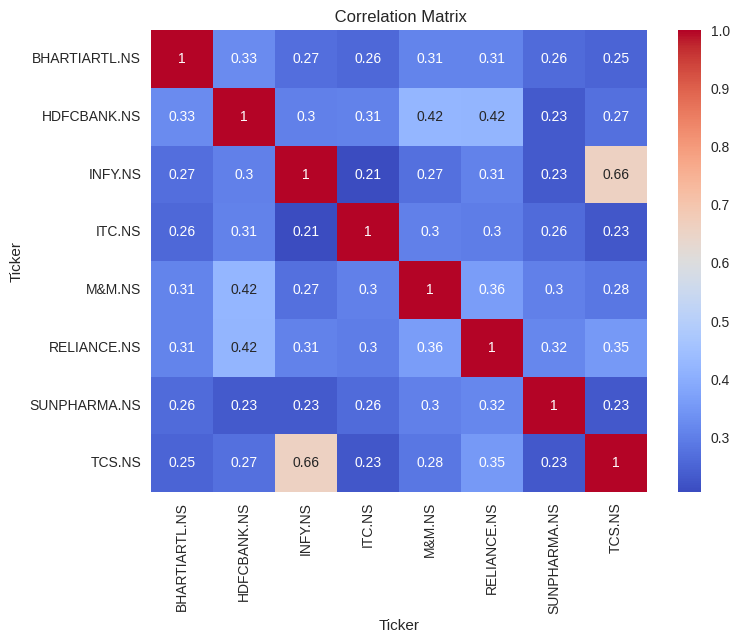

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(log_returns.corr(), annot=True, cmap="coolwarm")
plt.title(" Correlation Matrix")
plt.show()


The correlation matrix indicates moderate to low pairwise correlations across most assets, particularly between IT and banking stocks it also suggest that same nature of stock such as Infosys and Tcs have a correlation which is higher than most other stocks. This suggests meaningful diversification potential, as portfolio risk can be reduced through appropriate asset allocation rather than relying solely on individual asset selection.

# Monte Carlo Simulation

USING MONTE CARLO SIMULATION

---
What we are doing here is following:
1. Using simulation genrating thousands of porfolio
2. Calculating there risk,return and sharp ratio
3. Trying to depict various portfolio and there dominance and abnormality in comparison to one another



In [34]:
portfolio_number=10000
assets_number=len(mu)
results = np.zeros((3, portfolio_number))
weights_record = []

for i in range(portfolio_number):
    weights = np.random.random(assets_number)
    weights /= np.sum(weights)

    portfolio_return = np.dot(weights, mu)
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe_ratio = portfolio_return / portfolio_vol

    results[0,i] = portfolio_return
    results[1,i] = portfolio_vol
    results[2,i] = sharpe_ratio
    weights_record.append(weights)

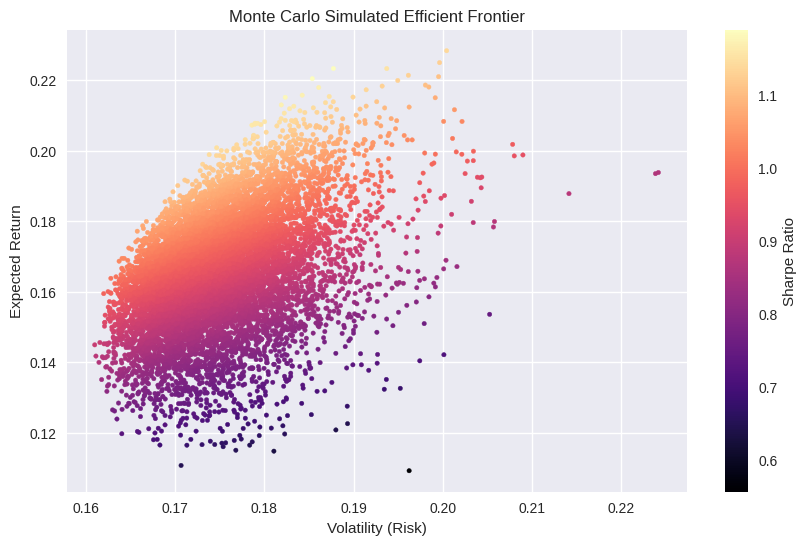

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(results[1], results[0], c=results[2], cmap='magma', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Monte Carlo Simulated Efficient Frontier')
plt.show()


In [36]:
max_sharpe_idx = np.argmax(results[2])
min_var_idx = np.argmin(results[1])

max_sharpe_weights = weights_record[max_sharpe_idx]
min_var_weights = weights_record[min_var_idx]


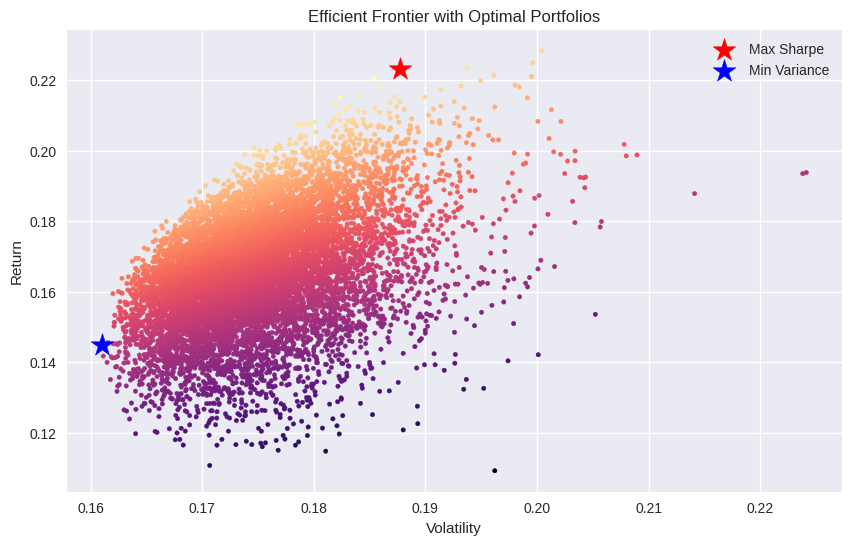

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(results[1], results[0], c=results[2], cmap='magma', s=10)
plt.scatter(results[1,max_sharpe_idx], results[0,max_sharpe_idx],
            marker='*', color='r', s=300, label='Max Sharpe')
plt.scatter(results[1,min_var_idx], results[0,min_var_idx],
            marker='*', color='b', s=300, label='Min Variance')
plt.legend()
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier with Optimal Portfolios')
plt.show()


Significant benefits of diversification across the chosen stocks are indicated by the Monte Carlo simulation's well-defined efficient frontier.
Although the maximum Sharpe portfolio is on the upper envelope and offers the most appealing risk-adjusted performance, the minimum variance portfolio achieves the lowest volatility at the expense of expected return.
Because of the curvature of the frontier, which allows for risk reduction through diversification, the impact of imperfect correlations between assets is highlighted

# Optimization

Constrained Portfolio Optimization using following:

1. Minimum Variance Portfolio

2.  Maximum Sharpe Portfolio



In [38]:
from scipy.optimize import minimize

In [39]:
#portfolio return function
def portfolio_return(weights, mu):
    return np.dot(weights, mu)


In [40]:
#portfolio volatility
def portfolio_volatility(weights, cov):
    return np.sqrt(np.dot(weights.T, np.dot(cov, weights)))


Minimum variance optimization adhere to folloeing two conditions:


1.   Weight sum equal to 1

2.   weight>=0



In [41]:
num_assets = len(mu)
init_guess = np.ones(num_assets) / num_assets

bounds = tuple((0,1) for _ in range(num_assets))

constraints = ({'type':'eq','fun': lambda w: np.sum(w)-1})


In [42]:
min_var = minimize(
    portfolio_volatility,
    init_guess,
    args=(cov,),
    method='SLSQP',             #SLSQP=sequential least square quadratic programming
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var.x


Maximum Sharpe optimization


1.  Maximize Sharpe
2.   Minimize negative sharpe




In [43]:
#risk free rate(rf)
rf=0.65
def neg_sharpe(weights, mu, cov, rf):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return -(ret - rf) / vol


In [44]:
max_sharpe = minimize(
    neg_sharpe,
    init_guess,
    args=(mu, cov, rf),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe.x


In [45]:
#comparing results to monto carlo
min_var_ret = portfolio_return(min_var_weights, mu)
min_var_vol = portfolio_volatility(min_var_weights, cov)

max_sharpe_ret = portfolio_return(max_sharpe_weights, mu)
max_sharpe_vol = portfolio_volatility(max_sharpe_weights, cov)


In [46]:
print("Min Variance Weights:", min_var_weights)
print("Max Sharpe Weights:", max_sharpe_weights)


Min Variance Weights: [0.10763327 0.16382673 0.03047567 0.22705074 0.         0.03562739
 0.19768836 0.23769784]
Max Sharpe Weights: [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.55782883e-16
 1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]


# Comparison with Nifty 50

In [47]:
nifty=yf.download("^NSEI", start="2019-04-01",end="2025-12-31")['Close']

/tmp/ipykernel_11256/3766503881.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty=yf.download("^NSEI", start="2019-04-01",end="2025-12-31")['Close']
[*********************100%***********************]  1 of 1 completed


In [48]:
nifty_returns = np.log(nifty / nifty.shift(1)).dropna()

In [49]:
common_index = log_returns.index.intersection(nifty_returns.index)

portfolio_returns = log_returns.loc[common_index].dot(max_sharpe_weights)
nifty_returns = nifty_returns.loc[common_index]

In [50]:
risk_free_rate = 0.07 / 252  # approx India

# Portfolio
p_return = portfolio_returns.mean() * 252
p_vol = portfolio_returns.std() * np.sqrt(252)
p_sharpe = (p_return - risk_free_rate) / p_vol

# NIFTY
n_return = nifty_returns.mean() * 252
n_vol = nifty_returns.std() * np.sqrt(252)
n_sharpe = (n_return - risk_free_rate) / n_vol

Comparison Table

In [51]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Return", "Volatility", "Sharpe Ratio"],
    "Optimized Portfolio": [p_return, p_vol, p_sharpe],
    "NIFTY 50": [n_return, n_vol, n_sharpe]
})

print(comparison)

         Metric  Optimized Portfolio                                 NIFTY 50
0        Return             0.264848  Ticker
^NSEI    0.120826
dtype: float64
1    Volatility             0.326287  Ticker
^NSEI    0.178939
dtype: float64
2  Sharpe Ratio             0.810852  Ticker
^NSEI    0.673681
dtype: float64


Plot performance

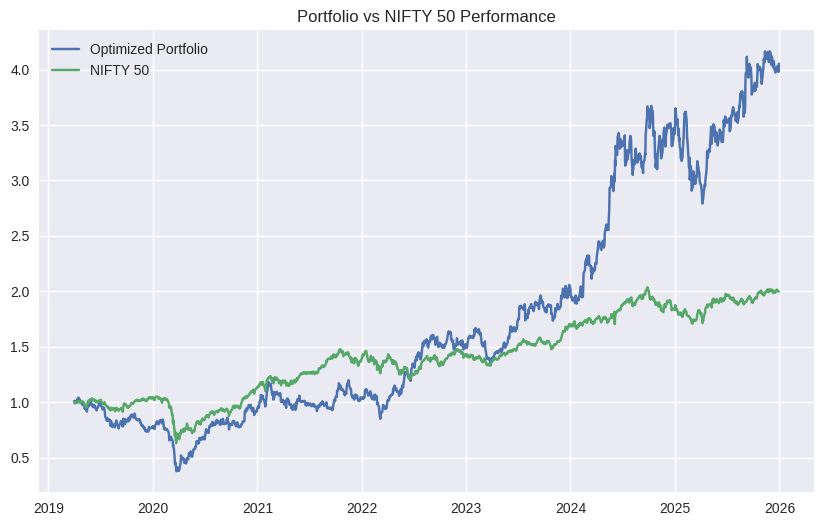

In [52]:
portfolio_cum = (1 + portfolio_returns).cumprod()
nifty_cum = (1 + nifty_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(portfolio_cum, label="Optimized Portfolio")
plt.plot(nifty_cum, label="NIFTY 50")
plt.title("Portfolio vs NIFTY 50 Performance")
plt.legend()
plt.show()

In [53]:
plt.savefig("portfolio_vs_nifty.png")

<Figure size 800x550 with 0 Axes>

## Key Insights and Conclusions

The optimized portfolio significantly outperformed the NIFTY 50 index over the analysis period, achieving substantially higher cumulative returns. However, this enhanced performance came with increased volatility and deeper drawdowns, particularly during market stress periods such as the 2020 crash.

These findings reinforce the central principle of Modern Portfolio Theory, which states that higher expected returns are associated with higher levels of risk. The portfolio demonstrated greater sensitivity to market conditions, underperforming during downturns while outperforming strongly in bullish phases.

It is important to note that the portfolio was optimized using historical data from the same time period, which may lead to overfitting. As a result, the observed performance may not be fully indicative of future results.

Overall, the results highlight both the strengths and limitations of mean–variance optimization in practical investment scenarios.
